# Выбор порогового коэффициента корреляции

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels
import yfinance as yf
from scipy import stats

In [2]:
plt.style.use('ggplot')

Рынок Германии, 10 низкокоррелированных акций:

In [3]:
de_tickers = ['FME.DE', 'FRE.DE', 'MRK.DE', 'VOW.DE', 'BEI.DE', 'IFX.DE', 'HEN3.DE', 'DTE.DE', 'SAP.DE', 'ADS.DE']

initial_df = yf.download(de_tickers, start='2006-01-01', end='2013-01-01', auto_adjust=True)['Close']
initial_df.head(5)

[*********************100%***********************]  10 of 10 completed


Ticker,ADS.DE,BEI.DE,DTE.DE,FME.DE,FRE.DE,HEN3.DE,IFX.DE,MRK.DE,SAP.DE,VOW.DE
Date,,,,,,,,,,
2006-01-02,32.206348,26.600298,5.008916,21.229231,8.686333,19.329485,5.661222,25.860992,27.469387,23.613806
2006-01-03,32.477024,27.111214,5.023136,21.329020,8.951610,19.050501,5.675831,25.779982,27.383327,24.137390
2006-01-04,32.951679,27.093422,5.055130,21.614141,9.060170,18.970789,5.843841,25.776299,27.637926,23.927958
2006-01-05,32.853607,26.994287,5.058685,21.528601,9.060170,19.043859,5.982634,25.625322,28.403498,23.671392
2006-01-06,32.808498,27.065454,5.097789,21.390800,9.141789,19.249775,6.150644,25.684240,28.624033,23.744701


In [4]:
df = pd.DataFrame([initial_df.iloc[row] / initial_df.iloc[row-1] for row in range(1, initial_df.shape[0])], index=initial_df.index[1:]) # расчет доходностей
df = np.log(df) # логарифмические доходности
df.dropna(inplace=True, axis=0)
df.head()

Ticker,ADS.DE,BEI.DE,DTE.DE,FME.DE,FRE.DE,HEN3.DE,IFX.DE,MRK.DE,SAP.DE,VOW.DE
Date,,,,,,,,,,
2006-01-03,0.008369,0.019025,0.002835,0.004690,0.030083,-0.014538,0.002577,-0.003137,-0.003138,0.021931
2006-01-04,0.014509,-0.000656,0.006349,0.013279,0.012055,-0.004193,0.029171,-0.000143,0.009255,-0.008715
2006-01-05,-0.002981,-0.003666,0.000703,-0.003965,0.000000,0.003844,0.023473,-0.005874,0.027323,-0.010780
2006-01-06,-0.001374,0.002633,0.007700,-0.006421,0.008968,0.010755,0.027696,0.002297,0.007734,0.003092
2006-01-09,-0.011000,-0.002162,-0.001395,-0.007022,0.008801,-0.007620,-0.008348,-0.000717,0.007985,0.010311


In [5]:
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 15)
corr_list = []

for year in range(2006, 2013):
  curr_year_df = df[df.index.year == year]
  year_corr = curr_year_df.corr() # выводим корреляционные матрицы
  corr_list.append(year_corr.where(np.triu(np.ones(year_corr.shape), k=1).astype(bool))) # сохраняем верхний треугольник для гистограммы
  print(f'{'-'*50}YEAR {year}{'-'*48}')
  print(f'{year_corr}\n')

--------------------------------------------------YEAR 2006------------------------------------------------
Ticker     ADS.DE    BEI.DE    DTE.DE    FME.DE    FRE.DE   HEN3.DE    IFX.DE    MRK.DE    SAP.DE    VOW.DE
Ticker                                                                                                     
ADS.DE   1.000000  0.401000  0.286373  0.347170  0.296589  0.255481  0.351127  0.306252  0.358524  0.318810
BEI.DE   0.401000  1.000000  0.236089  0.320726  0.355197  0.312790  0.402134  0.276394  0.328946  0.365328
DTE.DE   0.286373  0.236089  1.000000  0.347162  0.166881  0.280271  0.393895  0.163603  0.352143  0.280927
FME.DE   0.347170  0.320726  0.347162  1.000000  0.490945  0.349647  0.277846  0.214285  0.321378  0.359355
FRE.DE   0.296589  0.355197  0.166881  0.490945  1.000000  0.250504  0.255765  0.245629  0.272473  0.255628
HEN3.DE  0.255481  0.312790  0.280271  0.349647  0.250504  1.000000  0.247291  0.198179  0.369593  0.276115
IFX.DE   0.351127  0.402134 

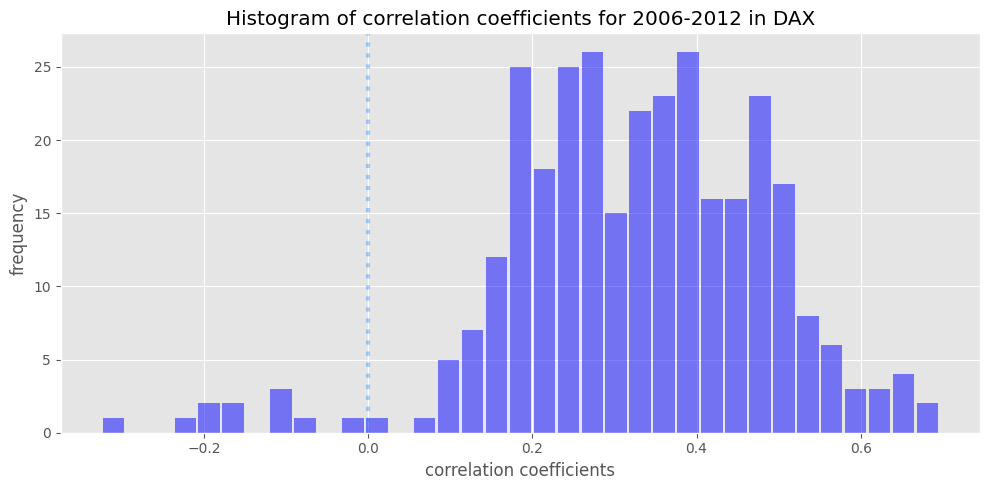

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.array(corr_list).flatten(), bins=35, color='#0000FF', rwidth=0.9, alpha=0.5)
ax.axvline(x=0, color='#1E90FF', linestyle=':', linewidth=3, alpha=0.4)
plt.xlabel('correlation coefficients', fontsize=12)
plt.ylabel('frequency', fontsize=12)
plt.title('Histogram of correlation coefficients for 2006-2012 in DAX')
plt.tight_layout()
plt.show()

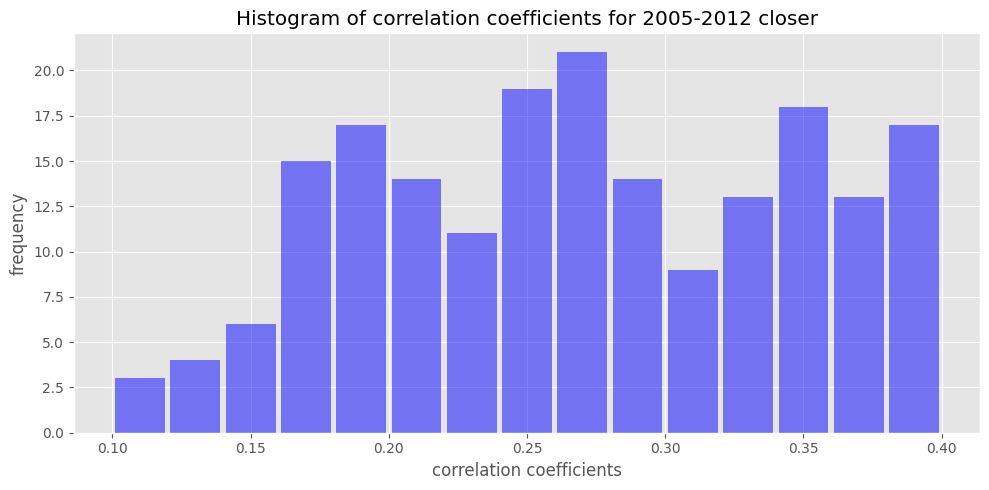

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.array(corr_list).flatten(), range=(0.10, 0.4), bins=15, color='#0000FF', rwidth=0.9, alpha=0.5)
plt.xlabel('correlation coefficients', fontsize=12)
plt.ylabel('frequency', fontsize=12)
plt.title('Histogram of correlation coefficients for 2005-2012 closer')
plt.tight_layout()
plt.show()

In [8]:
all_corrs = np.array(corr_list).flatten()
all_corrs_clean = all_corrs[~np.isnan(all_corrs)]

hist, bin_edges = np.histogram(all_corrs_clean, bins=75)
peak_bin = np.argmax(hist)
threshold = bin_edges[peak_bin]

print(f"Пик распределения: {threshold}")

Пик распределения: 0.2468012558060616


Выбор порогового значения коэффициента корреляции для проверки гипотезы осуществлялся на основе анализа эмпирического распределения. Пик распределения (мода) корреляционных коэффициентов за исследуемый период составил **0.25**.     
     
В качестве основного порога было выбрано значение **0.2**, что несколько ниже моды распределения. Данный выбор обусловлен следующими соображениями:   
*   Более низкий порог соответствует более строгому критерию "высокой корреляции";
*   Для инвестора значимым является превышение корреляций над уровнем, позволяющим строить диверсифицированный портфель;   
*   Робастность результатов: использование порога ниже моды позволяет проверить, сохраняется ли эффект при ужесточении критерия.   
